# OTT 이탈 예측 베이스라인

**타겟**: `churn = 1 - is_repurchase` (이탈=1, 잔류=0)  
**데이터**: `Membership_v2.csv` 원본 컬럼만 사용 (파생변수 없음)  
**모델**: Logistic Regression / Gradient Boosting / XGBoost / LightGBM / CatBoost

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    roc_curve, precision_recall_curve, auc
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 및 기본 확인

In [35]:
DATA_PATH = '../kim.kwangil/preprocessing/260509_view_delete/Membership_v2.csv'

df = pd.read_csv(DATA_PATH)
print(f'shape: {df.shape}')
df.head(3)

shape: (23343, 15)


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,is_repurchase
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4.0,1,0,pc,1,F,20.0,2021-03-14,20,2021-04-14,1
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1.0,1,1,pc,1,F,25.0,2021-03-09,14,2021-04-09,0
2,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.0,180,2.0,1,0,android,1,F,20.0,2021-03-09,2,2021-04-09,0


In [36]:
print('=== 결측치 ===')
print(df.isnull().sum())
print()
print('=== 타겟(is_repurchase) 분포 ===')
print(df['is_repurchase'].value_counts())
print(f'\n이탈률: {(df["is_repurchase"] == 0).mean():.2%}')

=== 결측치 ===
USER_KEY              0
product_code          0
price                 0
billing_method        0
max_screen            0
is_promotion          0
is_churn_prevented    0
payment_device        0
is_user_verified      0
gender                0
age                   0
reg_date              0
reg_hour              0
end_date              0
is_repurchase         0
dtype: int64

=== 타겟(is_repurchase) 분포 ===
is_repurchase
1    16702
0     6641
Name: count, dtype: int64

이탈률: 28.45%


## 2. 전처리 및 Train/Test 분리

In [37]:
# 타겟: 이탈=1, 잔류=0
df['churn'] = 1 - df['is_repurchase']

# ── 3주(21일) 관측 윈도우 필터 ──────────────────────────────────────
# subscription_days는 필터용으로만 계산, 피처로는 사용하지 않음
subscription_days = (pd.to_datetime(df['end_date']) - pd.to_datetime(df['reg_date'])).dt.days
before = len(df)
df = df[subscription_days >= 21].copy()
print(f'3주 필터 적용: {before}행 → {len(df)}행 (제거: {before - len(df)}행)')
print(f'필터 후 이탈률: {df["churn"].mean():.2%}')
# ────────────────────────────────────────────────────────────────────

# 원본 컬럼만 사용 (ID·날짜·타겟 제외, 파생변수 없음)
cat_cols = ['product_code', 'payment_device', 'gender']
num_cols = ['price', 'billing_method', 'max_screen',
            'is_promotion', 'is_churn_prevented', 'is_user_verified',
            'age', 'reg_hour']
TARGET = 'churn'

# Label Encoding (범주형)
df_enc = df[cat_cols + num_cols + [TARGET]].copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc[cat_cols + num_cols]
y = df_enc[TARGET]

# 80/20 분리 (stratify로 이탈률 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 이탈률: {y_train.mean():.2%} | Test 이탈률: {y_test.mean():.2%}')

3주 필터 적용: 23343행 → 23105행 (제거: 238행)
필터 후 이탈률: 28.24%

Train: (18484, 11), Test: (4621, 11)
Train 이탈률: 28.24% | Test 이탈률: 28.24%


In [38]:
# 로지스틱 회귀용 스케일링 (별도 유지)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [39]:
# 성능 측정 헬퍼
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    results = []
    for split, X_s, y_s in [('train', X_tr, y_tr), ('test', X_te, y_te)]:
        pred  = model.predict(X_s)
        proba = model.predict_proba(X_s)[:, 1]
        results.append({
            'model':     name,
            'split':     split,
            'accuracy':  accuracy_score(y_s, pred),
            'precision': precision_score(y_s, pred, zero_division=0),
            'recall':    recall_score(y_s, pred, zero_division=0),
            'f1':        f1_score(y_s, pred, zero_division=0),
            'auc':       roc_auc_score(y_s, proba),
        })
    return results

all_results = []
print('헬퍼 함수 준비 완료')

헬퍼 함수 준비 완료


## 3. 모델링

### 3-1. Logistic Regression

In [40]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

all_results.extend(evaluate('LogisticRegression', lr, X_train_sc, y_train, X_test_sc, y_test))

print('[ Logistic Regression ]')
print(classification_report(y_test, lr.predict(X_test_sc), target_names=['잔류', '이탈']))

[ Logistic Regression ]
              precision    recall  f1-score   support

          잔류       0.72      1.00      0.84      3316
          이탈       0.00      0.00      0.00      1305

    accuracy                           0.72      4621
   macro avg       0.36      0.50      0.42      4621
weighted avg       0.51      0.72      0.60      4621



### 3-2. Gradient Boosting (sklearn)

In [41]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)

all_results.extend(evaluate('GradientBoosting', gb, X_train, y_train, X_test, y_test))

print('[ Gradient Boosting ]')
print(classification_report(y_test, gb.predict(X_test), target_names=['잔류', '이탈']))

[ Gradient Boosting ]
              precision    recall  f1-score   support

          잔류       0.72      0.99      0.83      3316
          이탈       0.41      0.02      0.04      1305

    accuracy                           0.71      4621
   macro avg       0.57      0.50      0.44      4621
weighted avg       0.63      0.71      0.61      4621



### 3-3. XGBoost

In [42]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)

all_results.extend(evaluate('XGBoost', xgb_model, X_train, y_train, X_test, y_test))

print('[ XGBoost ]')
print(classification_report(y_test, xgb_model.predict(X_test), target_names=['잔류', '이탈']))

[ XGBoost ]
              precision    recall  f1-score   support

          잔류       0.72      0.99      0.83      3316
          이탈       0.35      0.01      0.03      1305

    accuracy                           0.71      4621
   macro avg       0.54      0.50      0.43      4621
weighted avg       0.61      0.71      0.61      4621



### 3-4. LightGBM

In [43]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train, y_train)

all_results.extend(evaluate('LightGBM', lgb_model, X_train, y_train, X_test, y_test))

print('[ LightGBM ]')
print(classification_report(y_test, lgb_model.predict(X_test), target_names=['잔류', '이탈']))

[ LightGBM ]
              precision    recall  f1-score   support

          잔류       0.72      0.99      0.83      3316
          이탈       0.38      0.02      0.03      1305

    accuracy                           0.71      4621
   macro avg       0.55      0.50      0.43      4621
weighted avg       0.62      0.71      0.61      4621



### 3-5. CatBoost

In [44]:
cat_model = CatBoostClassifier(
    iterations=200, learning_rate=0.1, depth=4,
    random_seed=42, verbose=0
)
cat_model.fit(X_train, y_train)

all_results.extend(evaluate('CatBoost', cat_model, X_train, y_train, X_test, y_test))

print('[ CatBoost ]')
print(classification_report(y_test, cat_model.predict(X_test), target_names=['잔류', '이탈']))

[ CatBoost ]
              precision    recall  f1-score   support

          잔류       0.72      1.00      0.83      3316
          이탈       0.32      0.00      0.01      1305

    accuracy                           0.72      4621
   macro avg       0.52      0.50      0.42      4621
weighted avg       0.60      0.72      0.60      4621



## 4. 모델 성능 비교 (Train vs Test — 과적합 확인)

In [45]:
result_df = pd.DataFrame(all_results)

pivot = result_df.pivot(index='model', columns='split', values=['accuracy', 'f1', 'auc'])
pivot.columns = [f'{m}_{s}' for m, s in pivot.columns]
pivot['f1_gap']  = pivot['f1_train']  - pivot['f1_test']
pivot['auc_gap'] = pivot['auc_train'] - pivot['auc_test']

display(pivot.round(4).style.background_gradient(cmap='RdYlGn_r', subset=['f1_gap', 'auc_gap']))

,accuracy_test,accuracy_train,f1_test,f1_train,auc_test,auc_train,f1_gap,auc_gap
model,,,,,,,,
CatBoost,0.716100,0.719600,0.009100,0.021500,0.584300,0.627600,0.012500,0.043300
GradientBoosting,0.715000,0.724800,0.042200,0.074200,0.573000,0.656600,0.032100,0.083600
LightGBM,0.715000,0.721800,0.029500,0.050600,0.573200,0.647700,0.021100,0.074400
LogisticRegression,0.717600,0.717600,0.000000,0.000000,0.577400,0.574700,0.000000,-0.002700
XGBoost,0.714100,0.721600,0.028000,0.052700,0.573200,0.651100,0.024700,0.077900


In [46]:
print('=== 전체 지표 (Test 기준) ===')
test_df = result_df[result_df['split'] == 'test'].set_index('model')
display(test_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].round(4))

=== 전체 지표 (Test 기준) ===


,accuracy,precision,recall,f1,auc
model,,,,,
LogisticRegression,0.7176,0.0000,0.0000,0.0000,0.5774
GradientBoosting,0.7150,0.4143,0.0222,0.0422,0.5730
XGBoost,0.7141,0.3519,0.0146,0.0280,0.5732
LightGBM,0.7150,0.3846,0.0153,0.0295,0.5732
CatBoost,0.7161,0.3158,0.0046,0.0091,0.5843


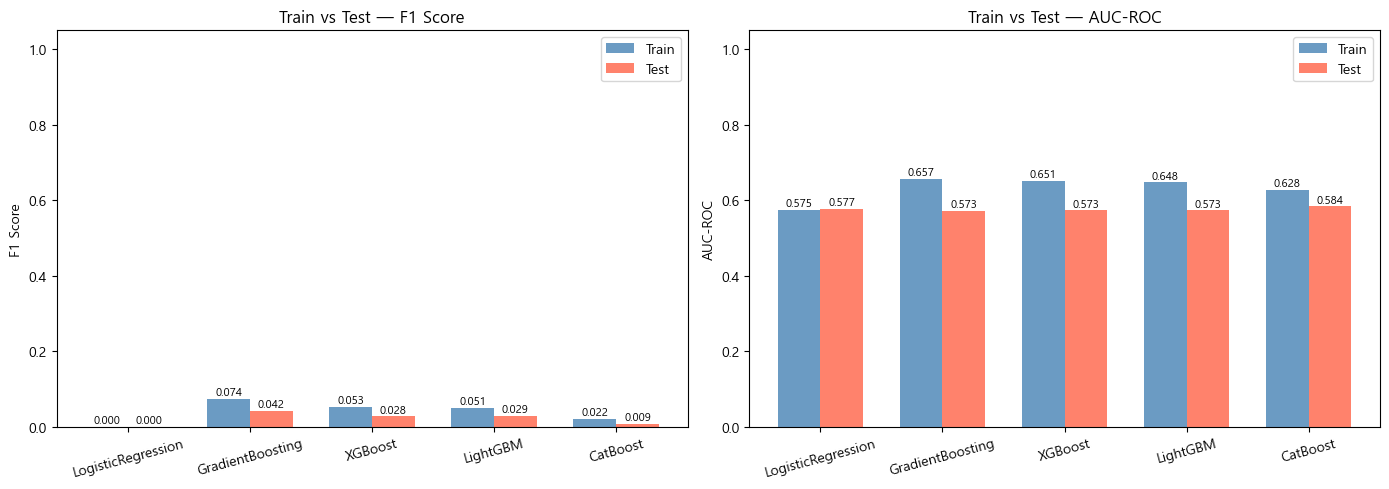

In [47]:
models    = result_df['model'].unique()
f1_train  = result_df[result_df['split'] == 'train'].set_index('model')['f1']
f1_test   = result_df[result_df['split'] == 'test'].set_index('model')['f1']
auc_train = result_df[result_df['split'] == 'train'].set_index('model')['auc']
auc_test  = result_df[result_df['split'] == 'test'].set_index('model')['auc']

x     = np.arange(len(models))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tr, te, ylabel, title) in zip(axes, [
    (f1_train,  f1_test,  'F1 Score',  'Train vs Test — F1 Score'),
    (auc_train, auc_test, 'AUC-ROC',   'Train vs Test — AUC-ROC'),
]):
    ax.bar(x - width/2, tr[models], width, label='Train', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, te[models], width, label='Test',  color='tomato',    alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1.05)
    for i, (a, b) in enumerate(zip(tr[models], te[models])):
        ax.text(i - width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
        ax.text(i + width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 5. AUC-ROC 커브 & PR 커브 (Test set)

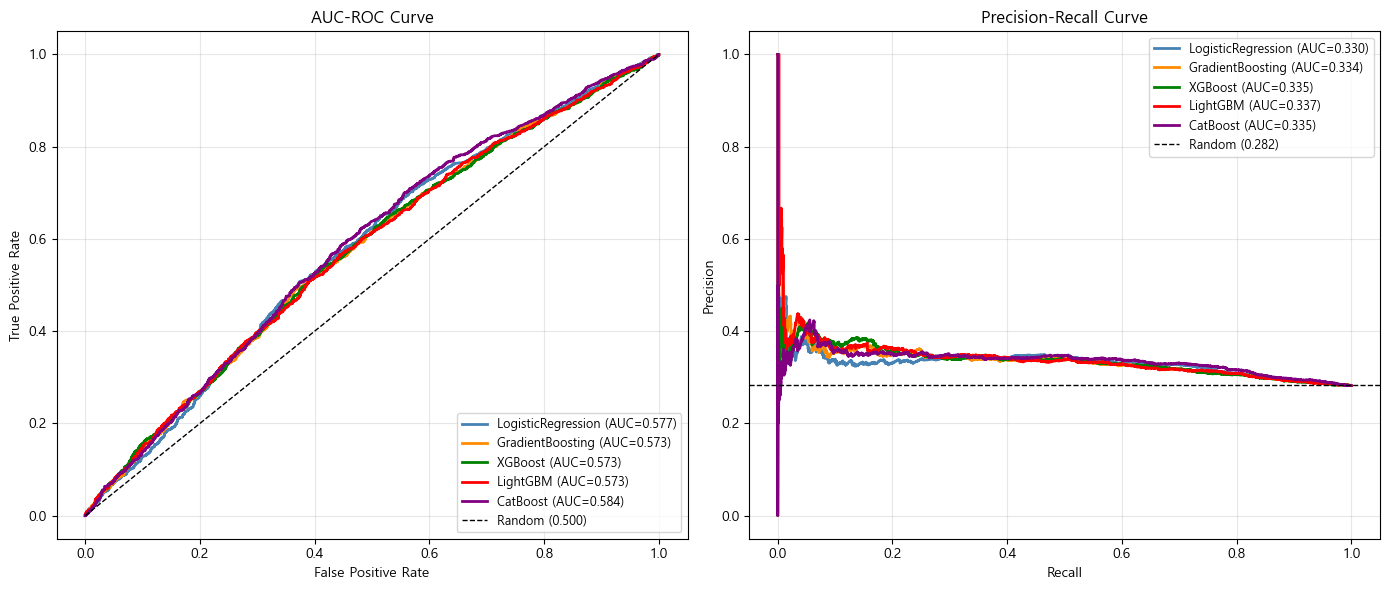

In [48]:
model_probas = {
    'LogisticRegression': lr.predict_proba(X_test_sc)[:, 1],
    'GradientBoosting':   gb.predict_proba(X_test)[:, 1],
    'XGBoost':            xgb_model.predict_proba(X_test)[:, 1],
    'LightGBM':           lgb_model.predict_proba(X_test)[:, 1],
    'CatBoost':           cat_model.predict_proba(X_test)[:, 1],
}
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, proba), color in zip(model_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('AUC-ROC Curve')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

baseline_precision = y_test.mean()
for (name, proba), color in zip(model_probas.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, color=color, lw=2, label=f'{name} (AUC={auc(recall, precision):.3f})')

axes[1].axhline(y=baseline_precision, color='k', linestyle='--', lw=1,
                label=f'Random ({baseline_precision:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SHAP 분석

- **Beeswarm**: 각 피처가 예측에 미치는 방향과 크기  
- **Bar plot**: 평균 |SHAP| 기준 피처 중요도  
- 트리 모델 4개 각각 분석 (TreeExplainer 사용)


  GradientBoosting


InvalidIndexError: (slice(None, None, None), 8)

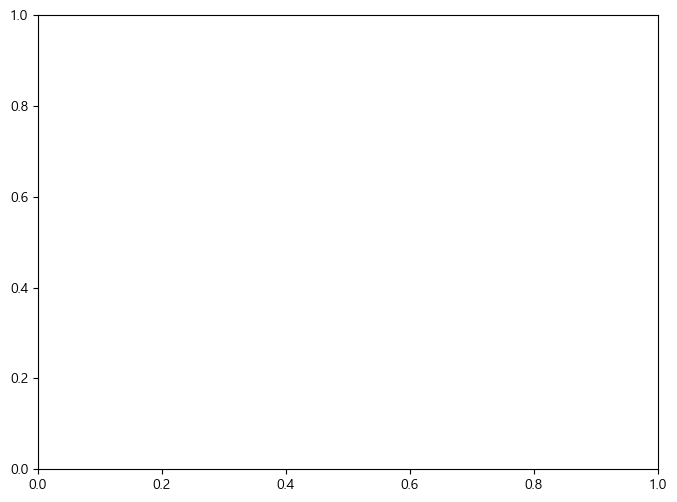

In [49]:
shap.initjs()

tree_models = {
    'GradientBoosting': gb,
    'XGBoost':          xgb_model,
    'LightGBM':         lgb_model,
    'CatBoost':         cat_model,
}

X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)

for name, model in tree_models.items():
    print(f'\n{"="*50}\n  {name}\n{"="*50}')

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # LightGBM binary는 list[2] 반환 → 이탈(class=1) 선택
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure()
    shap.summary_plot(sv, X_shap, feature_names=list(X_shap.columns),
                      plot_type='dot', show=False)
    plt.title(f'{name} — SHAP Beeswarm')
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(sv, X_shap, feature_names=list(X_shap.columns),
                      plot_type='bar', show=False)
    plt.title(f'{name} — SHAP Feature Importance (mean |SHAP|)')
    plt.tight_layout()
    plt.show()